<a href="https://colab.research.google.com/github/julesstrt/DLAV/blob/main/Copie_de_DLAV_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLAV Project - Phase 1

In this notebook we will train a very simple planner on data coming from a driving simulator. You are given a dash cam image of the current state of the driving vehicle, and the past positions of this vehicle, and you are asked to plan its future route.

This notebook will take you through steps on building this planner to solve the task. The full skeleton of the code together with some very simple implementations of each module are provided for your comfort. So all the cells below will run without you needing to change anything, but the performance won't be very good. You are asked to re-implement and play with most of the modules yourself to be able to have better performance.

P.S. to enable fast compute, you should use GPUs in google colab. The code works without GPUs, but it'll be much faster to use GPUs, specially if your model gets bigger and bigger! You can utilize Colab's GPUs by selecting "Change runtime type" in the Runtime menu on top of this page. There you can select "T4 GPU". This would restart your runtime, so you'll need to re-run everything from the top.

The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [ ]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=c844295b-f0c6-464b-95ef-f843e5344248
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:09<00:00, 47.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=fa0cbed2-029c-4762-b503-2c9e9b7b53d2
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:02<00:00, 33.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=d2f86e08-bfa1-4102-b7e6-d6481328d54c
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:01<00:00, 49.0MB/s]


Now lets load the data and visualize the first few examples to see what we are dealing with!

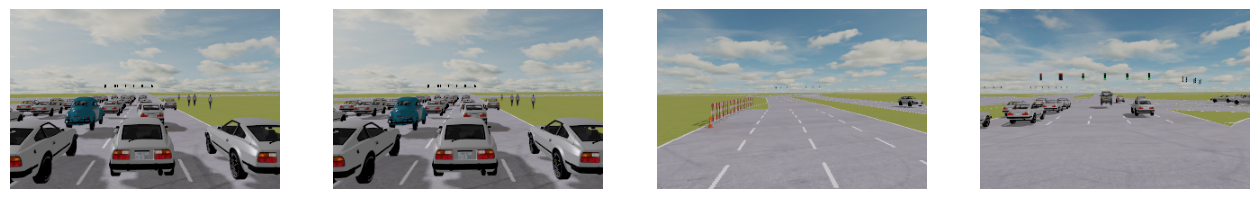

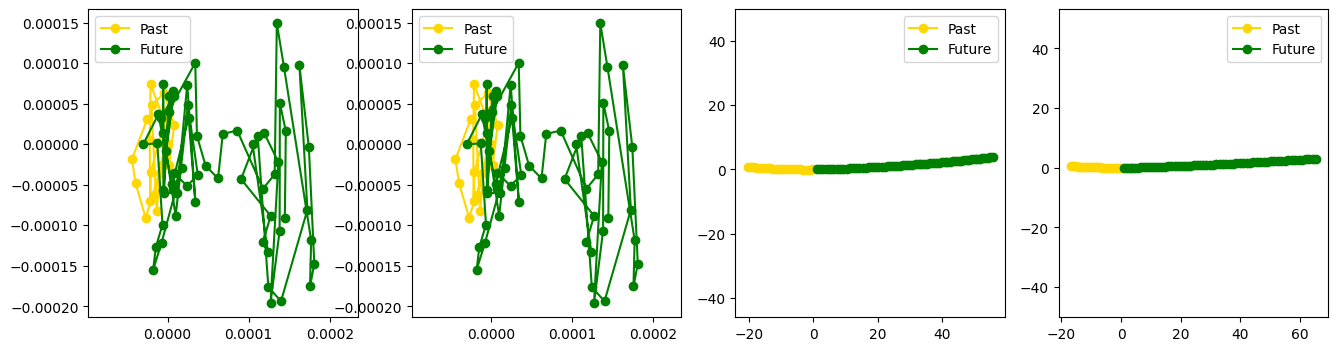

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random

k = 4
# load the data
data = []
for i in random.choices(np.arange(1000), k=k):
    with open(f"train/{i}.pkl", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now its time to make our hands dirty!

In the following cells we will define the classes we need to do a proper training in pytorch.

1. We will start with defining a Dataset class which loads the data and does some basic preprocessing. You can further process this data as you see fit.
2. We then define the logger which receives training metrics and logs and prints/visualizes them. Having a good logger means a lot when dealing with neural network training! The logger implemented here is very simple and we strongly suggest you try other ways of visualizing your losses and metrics. Be creative ;)
3. We then proceed with defining the core part of the pipeline, the model. You are going to mainly implement the model yourself, but we have provided a very simple model so that the code runs as is so that you can see how the whole framework runs all in all.
4. Finally, we define the training funciton which contains the training loop, and we call it to see the magic! You'll need to also do a lot of changes here, from the batch size and learning rate, to adding augmentation schemes and schedulers, etc.

## 1)Define DrivingDataset class

In [ ]:
import torch
from torch.utils.data import Dataset
import pickle
import torchvision.transforms as transforms
from torchvision.transforms import autoaugment
class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False, augment=False):
        self.samples = file_list
        self.test = test
        self.augment = augment

        if augment:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        camera = self.transform(data['camera'])
        history = torch.FloatTensor(data['sdc_history_feature'])
        driving_command = data['driving_command']

        if not self.test:
            # Dans DrivingDataset.__getitem__
            future = torch.FloatTensor(data['sdc_future_feature'][:, :2]) / 10.0
            return {
                'camera': camera,
                'history': history,
                'driving_command': driving_command,
                'future': future
            }
        else:
            return {
                'camera': camera,
                'history': history,
                'driving_command': driving_command
            }

## 2) Define a Logger class

In [ ]:
'''A logger is a utility that tracks, records, and visualizes metrics
during neural network training. Think of it as your "training dashboard"
it helps you monitor what's happening inside your model as it learns.'''
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
from collections import defaultdict
import time

class Logger:
    def __init__(self, log_dir='logs'):
        self.log_dir = log_dir
        os.makedirs(log_dir, exist_ok=True)

        self.train_losses = []
        self.val_losses = []
        self.ades = []
        self.fdes = []
        self.lrs = []
        self.epoch_times = []
        self.weight_ratios = []

    def log_batch(self, epoch, batch_idx, total_batches, loss):
        if batch_idx % 100 == 0:
            progress = batch_idx / total_batches * 100
            print(f"[Epoch {epoch}] Batch {batch_idx}/{total_batches} ({progress:.1f}%) | Loss: {loss:.4f}")

    def log_epoch_start(self, epoch):
        self.current_epoch = epoch
        self.start_time = time.time()

    def compute_weight_ratios(self, model, lr):
        """Calcule le ratio update/magnitude pour diagnostiquer le learning rate"""
        total_ratio = 0
        num_layers = 0

        for name, param in model.named_parameters():
            if param.grad is not None and param.data.abs().mean() > 1e-8:
                update_norm = torch.norm(param.grad.data * lr)
                param_norm = torch.norm(param.data)

                if param_norm > 1e-8:
                    ratio = (update_norm / param_norm).item()
                    total_ratio += ratio
                    num_layers += 1

        avg_ratio = total_ratio / max(num_layers, 1)
        self.weight_ratios.append(avg_ratio)

        print(f"\n📊 Weight Update / Weight Ratio: {avg_ratio:.2e}")
        if avg_ratio > 0.01:
            print(f"   ⚠️  Learning rate might be TOO HIGH!")
        elif avg_ratio < 1e-5:
            print(f"   ⚠️  Learning rate might be TOO LOW!")
        else:
            print(f"   ✅ Learning rate is in good range")

        return avg_ratio

    def log_epoch_end(self, train_loss, val_loss, ade, fde, lr, model=None):
        elapsed = time.time() - self.start_time
        self.epoch_times.append(elapsed)

        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.ades.append(ade)
        self.fdes.append(fde)
        self.lrs.append(lr)

        print(f"\n{'='*60}")
        print(f"Epoch {self.current_epoch} Summary:")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss:   {val_loss:.6f}")
        print(f"  ADE:        {ade:.4f}")
        print(f"  FDE:        {fde:.4f}")
        print(f"  LR:         {lr:.2e}")
        print(f"  Time:       {elapsed:.1f}s")
        print(f"{'='*60}\n")

        if model is not None:
            self.compute_weight_ratios(model, lr)

        self._plot_live()

    def _plot_live(self):
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Loss curves
        axes[0, 0].plot(self.train_losses, 'b-', label='Train Loss')
        axes[0, 0].plot(self.val_losses, 'r-', label='Val Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training & Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # ADE & FDE
        axes[0, 1].plot(self.ades, 'g-', label='ADE')
        axes[0, 1].plot(self.fdes, 'orange', label='FDE')
        axes[0, 1].axhline(y=2.0, color='r', linestyle='--', label='Target (ADE<2)')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Error (m)')
        axes[0, 1].set_title('Displacement Errors')
        axes[0, 1].legend()
        axes[0, 1].grid(True)

        # Learning rate
        axes[1, 0].semilogy(self.lrs, 'purple', marker='o')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].set_title('Learning Rate Schedule')
        axes[1, 0].grid(True)

        # Weight ratios
        if len(self.weight_ratios) > 0:
            axes[1, 1].plot(self.weight_ratios, 'brown', marker='o')
            axes[1, 1].axhline(y=0.001, color='g', linestyle='--', label='Good range (1e-3)')
            axes[1, 1].axhline(y=0.01, color='r', linestyle='--', label='Too high (1e-2)')
            axes[1, 1].axhline(y=1e-5, color='orange', linestyle='--', label='Too low (1e-5)')
            axes[1, 1].set_yscale('log')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Update/Weight Ratio')
            axes[1, 1].set_title('Weight Update Diagnostic')
            axes[1, 1].legend()
            axes[1, 1].grid(True)

        plt.tight_layout()
        plt.show()

    def save(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].plot(self.train_losses, label='Train Loss')
        axes[0].plot(self.val_losses, label='Val Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss Curves')
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(self.ades, label='ADE')
        axes[1].plot(self.fdes, label='FDE')
        axes[1].axhline(y=2.0, color='r', linestyle='--')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Error (m)')
        axes[1].set_title('Displacement Errors')
        axes[1].legend()
        axes[1].grid(True)

        plt.savefig(os.path.join(self.log_dir, 'training_curves.png'), dpi=150)
        plt.close()
        print(f"✅ Plots saved to {self.log_dir}/training_curves.png")

## 3) Define model architecture

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.models as models

# ============================================
# MODÈLE COMPLET
# ============================================
class DrivingPlanner(nn.Module):
    def __init__(self, history_dim=63, hidden_dim=512, output_timesteps=60, num_commands=3):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Identity()

        self.visual_proj = nn.Linear(512, 256)

        self.history_encoder = nn.Sequential(
            nn.Linear(history_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim)
        )

        # ⭐ Ajout: projection history → 256
        self.history_proj = nn.Linear(hidden_dim, 256)

        self.command_encoder = nn.Embedding(num_commands, 32)
        self.command_proj = nn.Linear(32, 256)

        # Transformer avec d_model=256 (inchangé)
        self.fusion_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=256,
                nhead=8,
                dim_feedforward=1024,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=4
        )

        self.pos_embed = nn.Parameter(torch.randn(1, 3, 256))

        self.decoder = nn.Sequential(
            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_timesteps * 2)
        )

        self.output_timesteps = output_timesteps

    def forward(self, camera, history, driving_command):
        B = camera.shape[0]

        visual_features = self.backbone(camera)
        visual_features = self.visual_proj(visual_features)

        history_flat = history.reshape(B, -1)
        history_features = self.history_encoder(history_flat)
        history_features = self.history_proj(history_features)  # ⭐ Projection ajoutée

        cmd_map = {'forward': 0, 'left': 1, 'right': 2}
        cmd_indices = torch.tensor([cmd_map[c] for c in driving_command], device=camera.device)
        cmd_features = self.command_encoder(cmd_indices)
        cmd_features = self.command_proj(cmd_features)

        # Maintenant tous les tokens sont en dimension 256
        tokens = torch.stack([visual_features, history_features, cmd_features], dim=1)
        tokens = tokens + self.pos_embed
        fused = self.fusion_transformer(tokens)
        fused = fused.mean(dim=1)

        future = self.decoder(fused)
        future = future.reshape(B, self.output_timesteps, 2)

        return future

## 4) Training setup

In [ ]:
def train(model, train_loader, val_loader, logger, num_epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-3,
        betas=(0.9, 0.999)
    )

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        logger.log_epoch_start(epoch)

        # Training
        model.train()
        train_loss = 0

        for batch_idx, batch in enumerate(train_loader):
            camera = batch['camera'].to(device)
            history = batch['history'].to(device)
            command = batch['driving_command']
            future = batch['future'].to(device)

            optimizer.zero_grad()
            pred_future = model(camera, history, command)
            loss = criterion(pred_future, future)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            logger.log_batch(epoch, batch_idx, len(train_loader), loss.item())

        # Validation
        model.eval()
        val_loss = 0
        ade_values = []
        fde_values = []

        with torch.no_grad():
            for batch in val_loader:
                camera = batch['camera'].to(device)
                history = batch['history'].to(device)
                command = batch['driving_command']
                future = batch['future'].to(device)

                pred_future = model(camera, history, command)
                loss = criterion(pred_future, future)

                ade = torch.norm(pred_future - future, p=2, dim=-1).mean()
                fde = torch.norm(pred_future[:, -1] - future[:, -1], p=2, dim=-1).mean()

                val_loss += loss.item()
                ade_values.append(ade.item())
                fde_values.append(fde.item())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        mean_ade = np.mean(ade_values)
        mean_fde = np.mean(fde_values)
        current_lr = optimizer.param_groups[0]['lr']

        logger.log_epoch_end(avg_train_loss, avg_val_loss, mean_ade, mean_fde, current_lr, model)
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  💾 Best model saved (Val Loss: {best_val_loss:.6f})")

    logger.save()
    print(f"\n✅ Training completed! Best val loss: {best_val_loss:.6f}")
    return model

## 5) Sanity check before training the model

In [ ]:
def sanity_check(model_class, train_dataset, device, num_samples=50, num_epochs=50):
    print("\n" + "="*60)
    print("🔍 SANITY CHECK - Testing if model can overfit")
    print("="*60)

    # Petit sous-ensemble
    small_indices = np.random.choice(len(train_dataset), num_samples, replace=False)
    small_dataset = torch.utils.data.Subset(train_dataset, small_indices)
    small_loader = DataLoader(small_dataset, batch_size=16, shuffle=True)

    # ⭐ Modèle avec horizon réduit à 10
    test_model = DrivingPlanner(output_timesteps=10)
    test_model = test_model.to(device)

    # Pas de régularisation
    optimizer = optim.Adam(test_model.parameters(), lr=1e-2, weight_decay=0.0)
    criterion = nn.MSELoss()

    print(f"  Training on {num_samples} samples for {num_epochs} epochs")
    print(f"  Output timesteps: 10")
    print(f"  Learning rate: 1e-2")

    losses = []

    for epoch in range(num_epochs):
        test_model.train()
        epoch_loss = 0

        for batch in small_loader:
            camera = batch['camera'].to(device)
            history = batch['history'].to(device)
            command = batch['driving_command']
            future = batch['future'].to(device)

            # ⭐ Prendre seulement les 10 premiers timesteps
            future_10 = future[:, :10, :]

            optimizer.zero_grad()
            pred_future = test_model(camera, history, command)
            loss = criterion(pred_future, future_10)  # ✅ Maintenant compatible
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(small_loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}: Loss = {avg_loss:.6f}")

    final_loss = losses[-1]

    print("\n" + "-"*60)
    print("Results:")
    print(f"  Initial loss: {losses[0]:.6f}")
    print(f"  Final loss:   {final_loss:.6f}")

    if final_loss < 0.1:
        print("  ✅ PASSED: Model can overfit!")
        return True
    else:
        print("  ❌ FAILED: Model cannot overfit!")
        return False

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
import os
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Chargement des données
train_data_dir = "train"
val_data_dir = "val"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files = [os.path.join(val_data_dir, f) for f in os.listdir(val_data_dir) if f.endswith('.pkl')]

# Datasets
train_dataset = DrivingDataset(train_files, augment=True)
val_dataset = DrivingDataset(val_files, augment=False)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# Modèle
model = DrivingPlanner()

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Sanity check (optionnel mais recommandé)
run_sanity = True  # Mettre à False pour skipper

if run_sanity:
    sanity_passed = sanity_check(DrivingPlanner(), train_dataset, device, num_samples=50, num_epochs=50)
    if not sanity_passed:
        print("\n⚠️  Sanity check failed! Consider adjusting model architecture.")

run_training = False  # Mettre à False pour skipper
if run_training:
    # Logger et entraînement
    logger = Logger(log_dir='logs')
    trained_model = train(model, train_loader, val_loader, logger, num_epochs=50)

Using device: cuda

🔍 SANITY CHECK - Testing if model can overfit
  Training on 50 samples for 50 epochs
  Output timesteps: 10
  Learning rate: 1e-2
  Epoch 10/50: Loss = 0.131692
  Epoch 20/50: Loss = 0.063418
  Epoch 30/50: Loss = 0.044107
  Epoch 40/50: Loss = 0.057075
  Epoch 50/50: Loss = 0.048352

------------------------------------------------------------
Results:
  Initial loss: 1.039607
  Final loss:   0.048352
  ✅ PASSED: Model can overfit!


By running the code above, you have trained your first model!
What do you observe in terms of train and val losses? What is this phenomenon called? (Explain in a few lines below)




This model is very simple and does not necessarilly yield the optimal performance. You are asked to implement your own neural network architecture. You can use convolution networks, vision transformers, etc. Try with different architectures, different model sizes, and other hyper parameters such as learning rate and batch size to find the best performance. Other ideas could be to use augmentation thechniques to boost the performance, adding learning rate schedulers, and exploring other loss functions.

Once you are happy with your model, continue with the rest of the notebook to save your checkpoint and also visualize some plans coming from the model. The last cell will provide a `submission_phase1.csv` which you can submit to the leaderboard to see your results on the testing set.

In [ ]:
# save the model
torch.save(model.state_dict(), "phase1_model.pth")

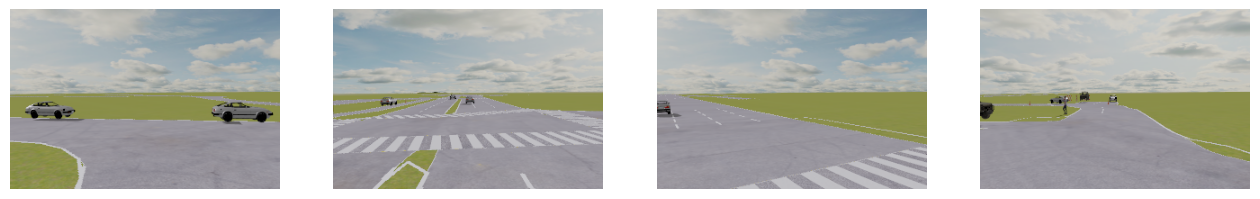

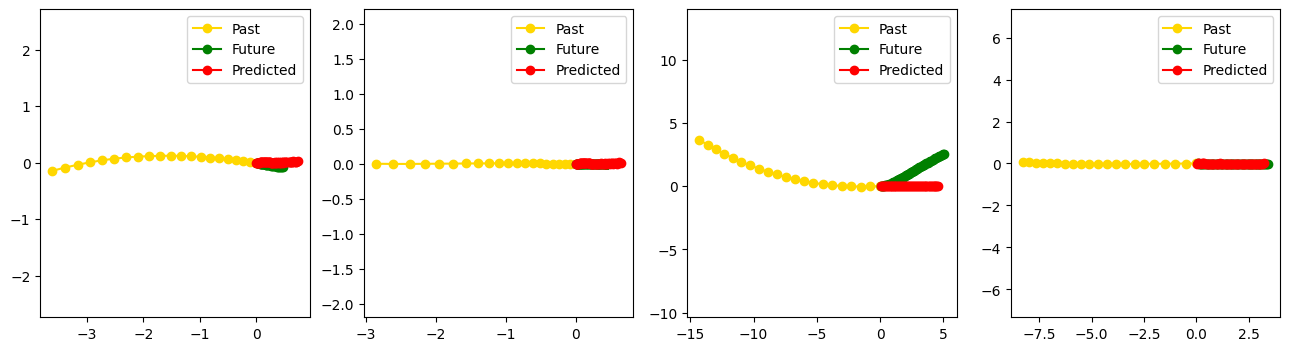

In [ ]:
def denormalize(image_tensor):
    """Dénormalise une image pour l'affichage"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor * std + mean
    return image.clamp(0, 1).permute(1, 2, 0).numpy()

val_batch_zero = next(iter(val_loader))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
camera = val_batch_zero['camera'].to(device)
history = val_batch_zero['history'].to(device)
command = val_batch_zero['driving_command']
future = val_batch_zero['future'].to(device)

model.eval()
with torch.no_grad():
    pred_future = model(camera, history, command)

camera = camera.cpu()
history = history.cpu().numpy()
future = future.cpu().numpy()
pred_future = pred_future.cpu().numpy()

# Si tu as normalisé les targets, remultiplie
# pred_future = pred_future * 10.0

k = 4
selected_indices = random.choices(np.arange(len(camera)), k=k)

# Affichage avec dénormalisation
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    img_denorm = denormalize(camera[idx])  # ← Dénormalisation
    axis[i].imshow(img_denorm)
    axis[i].axis("off")
plt.show()

# Trajectoires (inchangé)
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].plot(history[idx, :, 0], history[idx, :, 1], "o-", color="gold", label="Past")
    axis[i].plot(future[idx, :, 0], future[idx, :, 1], "o-", color="green", label="Future")
    axis[i].plot(pred_future[idx, :, 0], pred_future[idx, :, 1], "o-", color="red", label="Predicted")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called `submission_phase1.csv` by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

In [ ]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

dict_keys(['camera', 'depth', 'driving_command', 'sdc_history_feature', 'semantic_label'])


In [ ]:
import pandas as pd
test_data_dir = "test_public"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]

test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)


model.eval()
all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)
        command = batch['driving_command']


        pred_future = model(camera, history, command)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)
all_plans = all_plans * 10.0

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv("submission_phase1.csv", index=False)

print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (1000, 121)
